# Complete Guide to Rolling Windows Analysis

This notebook will guide you through analyzing text patterns using the Rolling Windows module. Whether you want to track word frequencies, compare character usage, or visualize how themes change throughout a document, this guide will show you exactly what to do.

> **Tip:** Before diving in, check out the project README for an overview of all components (within the whole module and this class) and how they fit together. This will help you understand the broader workflow and make the most of the Windows class.

## Table of Contents
1. [Setup and Prerequisites](#setup)
2. [Loading Your Text](#loading)
3. [Creating Windows](#windows)
4. [Choosing Your Analysis Type](#analysis)
   - [Counting Patterns](#counts)
   - [Calculating Averages](#averages)
   - [Comparing Ratios](#ratios)
5. [Visualizing Results](#plotting)
   - [Static Plots](#static)
   - [Interactive Plots](#interactive)
6. [Saving Your Work](#saving)

---

<a id="setup"></a>
## 1. Setup and Prerequisites

First, let's set up everything you need. Run this cell once at the beginning:

In [17]:
# Import all necessary components
import spacy
from lexos.rolling_windows import Windows
from lexos.rolling_windows.calculators.counts import Counts
from lexos.rolling_windows.calculators.averages import Averages
from lexos.rolling_windows.calculators.ratios import Ratios
from lexos.rolling_windows.plotters.simple_plotter import SimplePlotter
from lexos.rolling_windows.plotters.plotly_plotter import PlotlyPlotter
import pandas as pd

# Load the English language model
# If this fails, run: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

print("✓ Setup complete! You're ready to analyze text.")

✓ Setup complete! You're ready to analyze text.


> **Developers note**
    The spaCy model is required for token-based analysis and linguistic pattern matching. For character-only analysis, you could skip this, but it's recommended to load it anyway for flexibility.

---

<a id="loading"></a>
## 2. Loading Your Text

### Option A: Load from a File (Recommended)

In [18]:
# CHANGE THIS: Replace "A_Scandal_in_Bohemia.txt" with your filename
filename = "A_Scandal_in_Bohemia.txt"

try:
    with open(filename, "r", encoding="utf-8") as f:
        raw_text = f.read()
    print(f"✓ Loaded {len(raw_text)} characters from {filename}")
except FileNotFoundError:
    print(f"❌ Could not find {filename}")
    print("Make sure the file is in the same folder as this notebook")

✓ Loaded 51436 characters from A_Scandal_in_Bohemia.txt


### Option B: Paste Text Directly

In [19]:
# Alternative: Paste your text here
pasted_text = """
Your text goes here...
You can paste articles, stories, transcripts, etc.
"""
print(f"✓ Loaded {len(pasted_text)} characters")

✓ Loaded 75 characters


### Text Preparation (Optional but Recommended)

Many analyses work better with clean, normalized text:

In [20]:
# Basic text cleaning
import string

# Make lowercase (easier to match patterns)
text = raw_text.lower()

# Remove numbers (optional)
text = ''.join(char for char in text if not char.isdigit())

# Remove punctuation but keep special characters (like ð in Old English)
# CHANGE THIS: Add any special characters you want to keep
keep_chars = 'ð'  # Example for Old English, note that this doesn't occur in "A Scandal in Bohemia" but is just an example
punct = string.punctuation
text = ''.join(char for char in text if char not in punct or char in keep_chars)

print(f"✓ Cleaned text: {len(text)} characters")
print(f"Preview: {text[:200]}...")

✓ Cleaned text: 49361 characters
Preview: 



                              a scandal in bohemia

                               arthur conan doyle







                                table of contents
                                     ...


> **Tip** "When to Clean Text"
    - **Clean** when analyzing word patterns or general themes
    - **Don't clean** when analyzing punctuation, capitalization, or formatting

---

<a id="windows"></a>
## 3. Creating Windows

Windows are overlapping segments of your text. Think of it like a sliding frame that moves through your document.

### Choose Your Window Settings


In [21]:
# DECISION POINT: How do you want to segment your text?

# Option 1: By Characters (good for symbols, punctuation, letter patterns)
window_size = 1000  # CHANGE THIS: How many characters per window
window_type = "characters"

# Option 2: By Words/Tokens (good for word patterns, themes)
# window_size = 100  # CHANGE THIS: How many words per window
# window_type = "tokens"

# Option 3: By Lines (if your text has line breaks)
# window_size = 50  # CHANGE THIS: How many lines per window
# window_type = "tokens"  # Lines are treated as tokens

print(f"✓ Window settings: {window_size} {window_type} per window")

✓ Window settings: 1000 characters per window


### Create the Windows

In [22]:
# Create windows from your text
windows = Windows()

# For character or token-based analysis
if window_type == "tokens":
    # Process text with spaCy first (needed for word-based windows)
    doc = nlp(text[:1000000])  # Limit to 1M chars for memory
    sample_windows = windows(
        input=doc,
        n=window_size,
        window_type=window_type,
        output="strings"  # Human-readable output
    )
else:
    # Character-based windows
    sample_windows = windows(
        input=text,
        n=window_size,
        window_type=window_type,
        output="strings"
    )

# Note: Windows are generators that get consumed after use
# We'll create fresh windows for each analysis

# Check how many windows were created (without consuming them)
# We'll create a temporary window just for counting
temp_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    output="strings"
)
window_count = len(list(temp_windows))
print(f"✓ Created {window_count} overlapping windows")
print(f"Each position appears in up to {window_size} different windows")

# Note: We haven't used 'sample_windows' yet, so it's still fresh

✓ Created 48362 overlapping windows
Each position appears in up to 1000 different windows


> **Warning** "Important: Windows Get Consumed!"
    After using `sample_windows` once (like converting to a list), you need to create fresh windows for each calculator. This is why we'll create new windows in each analysis section.

---

<a id="analysis"></a>
## 4. Choosing Your Analysis Type

Now decide what kind of analysis you want to perform:

<a id="counts"></a>
### Option A: Count Patterns (Raw Frequencies)

Use this when you want to know **how many times** patterns appear in each window.

In [23]:
# CHANGE THESE: Your patterns to search for
patterns_to_count = ["a", "e"] # Example: Common letters
# patterns_to_count = ["love", "hate"]  # Example: Emotion words
# patterns_to_count = ["he", "she", "they"]  # Example: Pronouns

# Create fresh windows for counting
count_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

# Count the patterns
counter = Counts(
    patterns=patterns_to_count,
    windows=count_windows,
    mode="exact",  # Exact matching (see advanced options below)
    case_sensitive=False  # Ignore uppercase/lowercase
)

# Get results as a table
count_results = counter.to_df()
print(f"✓ Counted patterns in {len(count_results)} windows")
print("\nFirst 5 windows:")
print(count_results.head())
print(f"\nTotal occurrences:")
print(count_results.sum())

✓ Counted patterns in 0 windows

First 5 windows:
Empty DataFrame
Columns: [a, e]
Index: []

Total occurrences:
a    0
e    0
dtype: object


#### Advanced Search Modes

In [24]:
# For more complex pattern matching:

# 1. Regular Expressions (regex)
# Example: Find all words starting with "br"
# regex_patterns = ["^br.*"]
# mode = "regex"

# 2. Linguistic Patterns (requires token windows with token output)
# Example: Find all nouns
# spacy_patterns = [[{"POS": "NOUN"}]]
# mode = "spacy_rule"
# Note: Requires output="tokens" in windows

# 3. Multi-word Phrases
# Example: Find "once upon"
# phrase_patterns = ["once upon"]
# mode = "multi_token_exact"

> **Developers note**
    - `exact` mode uses Python's string `count()` method
    - `regex` mode uses `re.findall()` with case-insensitive flags
    - `spacy_rule` mode requires spaCy Token objects, not strings
    - See the README for full pattern matching documentation

<a id="averages"></a>
### Option B: Calculate Averages (Normalized Frequencies)

Use this when you want to know **how often** patterns appear (frequency per unit). This is better for comparing across different window sizes.

In [25]:
# CHANGE THESE: Your patterns to analyze
patterns_to_average = ["a", "e"]  # Same format as counting

# Create fresh windows for averaging
avg_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

# Calculate averages
averager = Averages(
    patterns=patterns_to_average,
    windows=avg_windows,
    mode="exact",
    case_sensitive=False
)

# Get results
avg_results = averager.to_df()
print(f"✓ Calculated average frequencies in {len(avg_results)} windows")
print("\nFirst 5 windows:")
print(avg_results.head())
print(f"\nOverall average frequency:")
print(avg_results.mean())

✓ Calculated average frequencies in 0 windows

First 5 windows:
Empty DataFrame
Columns: [a, e]
Index: []

Overall average frequency:
a    NaN
e    NaN
dtype: object


**When to use Averages instead of Counts:**
- Comparing texts of different lengths
- Comparing different window sizes
- Creating standardized measurements
- Academic/scientific analysis

<a id="ratios"></a>
### Option C: Compare Ratios (Relative Frequencies)

Use this when you want to compare the **balance between two patterns**.

In [26]:
# CHANGE THESE: Exactly 2 patterns to compare
patterns_to_compare = ["a", "e"]  # Will calculate a / (a + e)
# patterns_to_compare = ["positive", "negative"]  # Example sentiment
# patterns_to_compare = ["past", "present"]  # Example tense

# Create fresh windows for ratios
ratio_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

# Calculate ratios
ratio_calc = Ratios(
    patterns=patterns_to_compare,
    windows=ratio_windows,
    mode="exact",
    case_sensitive=False
)

# Get results
ratio_results = ratio_calc.to_df()
print(f"✓ Calculated ratios in {len(ratio_results)} windows")
print("\nFirst 5 windows:")
print(ratio_results.head())

# Interpret the results
avg_ratio = ratio_results.iloc[:, 0].mean()
print(f"\nAverage ratio: {avg_ratio:.3f}")
if avg_ratio > 0.5:
    print(f"→ '{patterns_to_compare[0]}' appears more frequently overall")
elif avg_ratio < 0.5:
    print(f"→ '{patterns_to_compare[1]}' appears more frequently overall")
else:
    print("→ Both patterns appear equally overall")

✓ Calculated ratios in 0 windows

First 5 windows:
Empty DataFrame
Columns: [a:e]
Index: []

Average ratio: nan
→ Both patterns appear equally overall


**Understanding Ratios:**
- 0.0 = Only the second pattern appears
- 0.5 = Both patterns appear equally
- 1.0 = Only the first pattern appears

> **Warning** "Ratios Requirement"
    Ratios calculator requires exactly 2 patterns. For comparing multiple patterns, use Counts or Averages instead.

---

<a id="plotting"></a>
## 5. Visualizing Results

Now let's create visualizations of your analysis. Choose between static plots (for reports) or interactive plots (for exploration).

<a id="static"></a>
### Option A: Static Plots (SimplePlotter)

Best for: Reports, publications, presentations

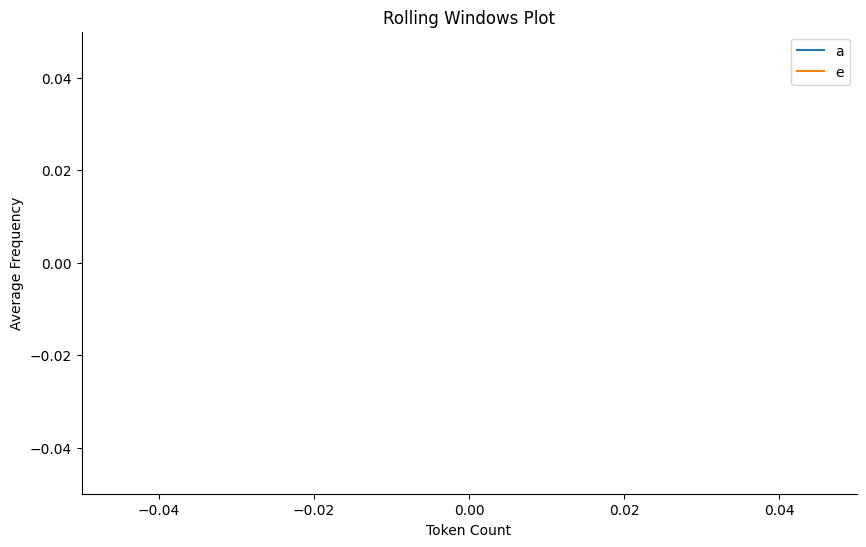

In [27]:
# CHANGE THIS: Use your results from above
data_to_plot = avg_results  # or count_results or ratio_results

# Create a static plot
static_plotter = SimplePlotter(
    title="Pattern Frequency Analysis",  # CHANGE THIS
    xlabel="Window Position",
    ylabel="Frequency",  # CHANGE THIS based on your analysis type
    figsize=(10, 6),  # (width, height) in inches
    show_legend=True,
    show_grid=True
)

# Generate the plot
static_plotter(df=data_to_plot)

# Optional: Save the plot
# static_plotter.save("sample_analysis.png", dpi=300)
# static_plotter.save("sample_analysis.pdf")  # For publications

#### Adding Milestones (Optional)

Milestones mark important points in your text:

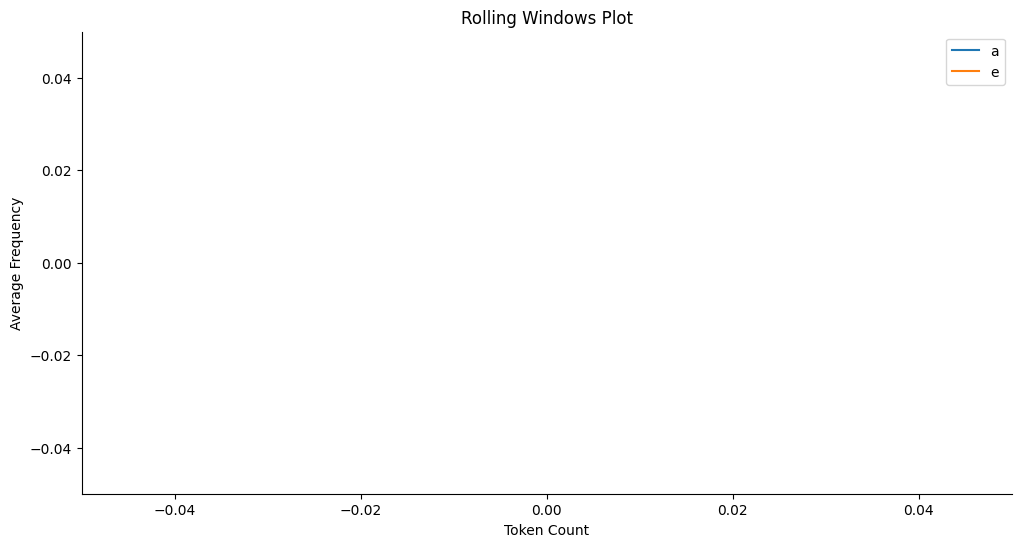

In [28]:
# CHANGE THESE: Define important positions in your text
# Example: Mark where specific events/topics occur
milestones = {
    "Chapter 1": 0,      # Window number where Chapter 1 starts
    "Chapter 2": 50,     # Window number where Chapter 2 starts
    "Chapter 3": 100,    # Window number where Chapter 3 starts
}

# Create plot with milestones
milestone_plotter = SimplePlotter(
    title="Analysis with Chapter Markers",
    figsize=(12, 6),
    show_milestones=True,
    milestone_labels=milestones,
    milestone_colors="red",
    milestone_style="--",  # Dashed lines
    show_milestone_labels=True,
    milestone_labels_rotation=45
)

milestone_plotter(df=data_to_plot)

<a id="interactive"></a>
### Option B: Interactive Plots (PlotlyPlotter)

Best for: Exploration, web presentation, detailed analysis

In [29]:
# CHANGE THIS: Use your results from above
data_to_plot = avg_results  # or count_results or ratio_results

# Create an interactive plot
interactive_plotter = PlotlyPlotter(
    title="Interactive Pattern Analysis",  # CHANGE THIS
    xlabel="Window Position",
    ylabel="Frequency",  # CHANGE THIS based on your analysis type
    width=1000,  # pixels
    height=600,  # pixels
    showlegend=True
)

# Generate the plot (opens in browser)
interactive_plotter(df=data_to_plot)

# Optional: Save as interactive HTML
# interactive_plotter.save("sample_analysis.html")

**Interactive Features:**
- Hover over points to see exact values
- Zoom in/out with mouse
- Pan by dragging
- Click legend items to show/hide lines
- Download plot as PNG using camera icon

> **Tip** "Which Plotter to Use?"
    - **SimplePlotter**: When you need high-quality static images for papers or presentations
    - **PlotlyPlotter**: When you want to explore the data or share interactive results

---

<a id="saving"></a>
## 6. Saving Your Work

Don't forget to save your results!

### Save the Data

In [30]:
# Save your numerical results as CSV
data_to_plot.to_csv("sample_outputs/sample_analysis_data.csv", index=True)
print("✓ Saved data to sample_analysis_data.csv")

# Create a summary report
summary = pd.DataFrame({
    'Pattern': data_to_plot.columns,
    'Total': data_to_plot.sum().values,
    'Average': data_to_plot.mean().values,
    'Max': data_to_plot.max().values,
    'Min': data_to_plot.min().values
})
print("\nSummary Report:")
print(summary)

# Save summary
summary.to_csv("sample_outputs/sample_analysis_summary.csv", index=False)
print("✓ Saved summary to sample_analysis_summary.csv")

✓ Saved data to sample_analysis_data.csv

Summary Report:
  Pattern Total Average  Max  Min
0       a     0     NaN  NaN  NaN
1       e     0     NaN  NaN  NaN
2      id     0     NaN  NaN  NaN
✓ Saved summary to sample_analysis_summary.csv


### Save the Plots

In [31]:
# For static plots (SimplePlotter)
if 'static_plotter' in locals():
    static_plotter.save("sample_outputs/sample_analysis_plot.png", dpi=300, bbox_inches='tight')
    static_plotter.save("sample_outputs/sample_analysis_plot.pdf", bbox_inches='tight')
    print("✓ Saved static plots")

# For interactive plots (PlotlyPlotter)
if 'interactive_plotter' in locals():
    interactive_plotter.save("sample_outputs/sample_analysis_interactive.html")
    print("✓ Saved interactive plot as HTML")

✓ Saved static plots
✓ Saved interactive plot as HTML


---

## Complete Example Workflow

Here's everything together in one workflow:

✓ Analysis complete!


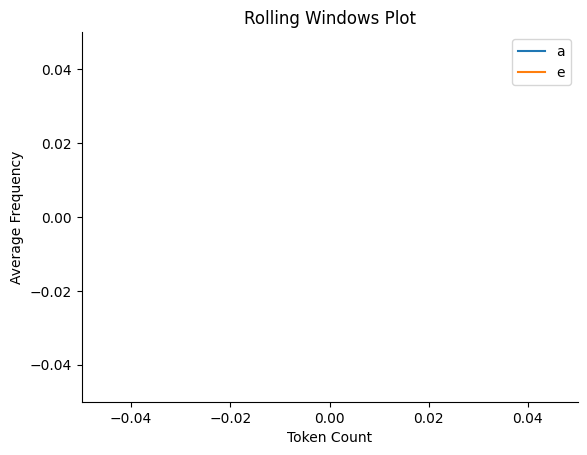

In [32]:
# 1. Load and prepare text
with open("A_Scandal_in_Bohemia.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

# 2. Create windows (1000 characters each)
windows = Windows()
analysis_windows = windows(input=text, n=1000, window_type="characters", output="strings")

# 3. Calculate average frequencies of 'a' and 'e'
calculator = Averages(patterns=["a", "e"], windows=analysis_windows)
results = calculator.to_df()

# 4. Create visualization
plotter = SimplePlotter(title="'a' and 'e' in A Scandal in Bohemia")
plotter(df=results)

# 5. Save everything
plotter.save("sample_outputs/Bohemia_analysis.png")
results.to_csv("sample_outputs/Bohemia_data.csv")

print("✓ Analysis complete!")

---

## Quick Reference

### Changing Analysis Types

| Goal | Calculator | Key Setting |
|------|-----------|-------------|
| Count occurrences | `Counts` | `patterns=["word1", "word2"]` |
| Compare frequencies | `Averages` | `patterns=["word1", "word2"]` |
| Analyze balance | `Ratios` | `patterns=["word1", "word2"]` (exactly 2) |

### Window Size Guidelines

| Text Type | Window Type | Suggested Size |
|-----------|-------------|----------------|
| Short text | characters | 50-200 |
| Novel/Book | characters | 500-2000 |
| Short text | tokens | 10-50 |
| Novel/Book | tokens | 50-200 |

### Pattern Examples

| Pattern Type | Example | Mode |
|--------------|---------|------|
| Exact words | `["love", "hate"]` | `"exact"` |
| Word starts | `["^love.*"]` | `"regex"` |
| Word ends | `[".*ing$"]` | `"regex"` |
| Any noun | `[[{"POS": "NOUN"}]]` | `"spacy_rule"` |

---

## Need More Help?

- For detailed parameter explanations, see the README
- For advanced pattern matching, check the spaCy documentation
- For visualization options, see matplotlib (SimplePlotter) or Plotly documentation

Remember: Start simple, then add complexity as needed!